# Workflow for a single node energy system

In this application of the ETHOS.FINE framework, a single region energy system is modeled and optimized.

All classes which are available to the user are utilized and examples of the selection of different parameters within these classes are given.

The workflow is structures as follows:
1. Required packages are imported and the input data path is set
2. An energy system model instance is created
3. Commodity sources are added to the energy system model
4. Commodity conversion components are added to the energy system model
5. Commodity storages are added to the energy system model
7. Commodity sinks are added to the energy system model
8. The energy system model is optimized
9. Selected optimization results are presented


# 1. Import required packages and set input data path

The ETHOS.FINE framework is imported which provides the required classes and functions for modeling the energy system.

In [1]:
import fine as fn
from getData import getData
from pathlib import Path


cwd = Path.cwd()
data = getData()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 2. Create an energy system model instance 

The structure of the energy system model is given by the considered locations, commodities, the number of time steps as well as the hours per time step.

The commodities are specified by a unit (i.e. 'GW_electric', 'GW_H2lowerHeatingValue', 'Mio. t CO2/h') which can be given as an energy or mass unit per hour. Furthermore, the cost unit and length unit are specified.

In [2]:
locations = {"GermanyRegion"}
onlycommodityUnitsDict = {"electricity": r"GW$_{el}$", "hydrogen": r"GW$_{H_{2},LHV}$"}
onlycommodities = {"electricity", "hydrogen"}
onlymaterials={"steel", "copper"},
onlymaterialUnitsDict={"steel": "tons", "copper": "kg"}
numberOfTimeSteps = 8760
hoursPerTimeStep = 1

In [3]:
esM = fn.EnergySystemModel(
    locations=locations,
    onlycommodities=onlycommodities,
    onlymaterials={"steel", "copper"}, 
    numberOfTimeSteps=8760,
    onlycommodityUnitsDict=onlycommodityUnitsDict,
    onlymaterialUnitsDict={"steel": "tons", "copper": "kg"},
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
)

# 3. Add commodity sources to the energy system model

## 3.1. Electricity sources

### Wind onshore

In [4]:
import pandas as pd

esM.add(
    fn.Source(
        esM=esM,
        name="Wind (onshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
        materialIntensity = {
            'GermanyRegion': {
                'steel': pd.Series({0: 3.1}, dtype='float64'),
                'copper': pd.Series({0: 5.3}, dtype='float64')  
            }
        }
    )
)

esM.add(
    fn.Source(
        esM=esM,
        name="Wind (offshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
        materialIntensity = {
            'GermanyRegion': {
                'steel': pd.Series({0: 3.1}, dtype='float64'),
                'copper': pd.Series({0: 5.3}, dtype='float64')  
            }
        }
    )
)

Full load hours:

In [5]:
data["Wind (onshore), operationRateMax"].sum()

2300.4069071646272

# 4. Add conversion components to the energy system model

### New combined cycly gas turbines for hydrogen

In [6]:
# esM.add(
#     fn.Conversion(
#         esM=esM,
#         name="New CCGT plants (hydrogen)",
#         physicalUnit=r"GW$_{el}$",
#         commodityConversionFactors={"electricity": 1, "hydrogen": -1 / 0.6},
#         hasCapacityVariable=True,
#         investPerCapacity=0.7,
#         opexPerCapacity=0.021,
#         interestRate=0.08,
#         economicLifetime=33,
#         materialIntensity = {
#             'GermanyRegion': {
#                 'steel': pd.Series({0: 7.1}, dtype='float64'),
#                 'copper': pd.Series({0: 6.3}, dtype='float64')  
#             }
#         }
#     )
# )

### Electrolyzers

In [7]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="Electroylzers",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": -1, "hydrogen": 0.7},
        hasCapacityVariable=True,
        investPerCapacity=0.5,
        opexPerCapacity=0.5 * 0.025,
        interestRate=0.08,
        economicLifetime=10,
    )
)

# 5. Add commodity storages to the energy system model

## 5.1. Electricity storage

### Lithium ion batteries

The self discharge of a lithium ion battery is here described as 3% per month. The self discharge per hours is obtained using the equation (1-$\text{selfDischarge}_\text{hour})^{30*24\text{h}} = 1-\text{selfDischarge}_\text{month}$.

In [8]:
# esM.add(
#     fn.Storage(
#         esM=esM,
#         name="Li-ion batteries",
#         commodity="electricity",
#         hasCapacityVariable=True,
#         chargeEfficiency=0.95,
#         cyclicLifetime=10000,
#         dischargeEfficiency=0.95,
#         selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
#         chargeRate=1,
#         dischargeRate=1,
#         doPreciseTsaModeling=False,
#         investPerCapacity=0.151,
#         opexPerCapacity=0.002,
#         interestRate=0.08,
#         economicLifetime=22,
#         materialIntensity = {
#             'GermanyRegion': {
#                 'steel': pd.Series({0: 9.1}, dtype='float64'),
#                 'copper': pd.Series({0: 2.3}, dtype='float64')  
#             }
#         }
#     )
# )

## 5.2. Hydrogen storage

### Hydrogen filled salt caverns
The maximum capacity is here obtained by: dividing the given capacity (which is given for methane) by the lower heating value of methane and then multiplying it with the lower heating value of hydrogen.

In [9]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Salt caverns (hydrogen)",
        commodity="hydrogen",
        hasCapacityVariable=True,
        capacityVariableDomain="continuous",
        capacityPerPlantUnit=133,
        chargeRate=1 / 470.37,
        dischargeRate=1 / 470.37,
        sharedPotentialID="Existing salt caverns",
        stateOfChargeMin=0.33,
        stateOfChargeMax=1,
        capacityMax=data["Salt caverns (hydrogen), capacityMax"],
        investPerCapacity=0.00011,
        opexPerCapacity=0.00057,
        interestRate=0.08,
        economicLifetime=30,
    )
)

# 7. Add commodity sinks to the energy system model

## 7.1. Electricity sinks

### Electricity demand

In [10]:
esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=data["Electricity demand, operationRateFix"],
    )
)

## 7.2. Hydrogen sinks

### Fuel cell electric vehicle (FCEV) demand

In [11]:
FCEV_penetration = 0.5
esM.add(
    fn.Sink(
        esM=esM,
        name="Hydrogen demand",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateFix=data["Hydrogen demand, operationRateFix"] * FCEV_penetration,
    )
)

In [12]:
sink = esM.add(
    fn.Sink(
        esM=esM,
        name="Steel demand",
        hasCapacityVariable=False,
        commodity="steel",
        material=True,      
    )
)

sink = esM.add(
    fn.Sink(
        esM=esM,
        name="Copper demand",
        hasCapacityVariable=False,
        commodity="copper",
        material=True,      
    )
)

# 8. Optimize energy system model

All components are now added to the model and the model can be optimized. If the computational complexity of the optimization should be reduced, the time series data of the specified components can be clustered before the optimization and the parameter timeSeriesAggregation is set to True in the optimize call.

In [13]:
esM.aggregateTemporally(numberOfTypicalPeriods=30)


Clustering time series data with 30 typical periods and 24 time steps per period 
further clustered to 12 segments per period...
		(4.8834 sec)



In [14]:
esM.optimize(timeSeriesAggregation=True, solver="glpk")

Time series aggregation specifications:
Number of typical periods:30, number of time steps per period:24, number of segments per period:12

Declaring sets, variables and constraints for SourceSinkModel
	declaring sets... 
('GermanyRegion', 'Steel demand', 'Wind (onshore)', 'steel', 0)
('GermanyRegion', 'Steel demand', 'Wind (onshore)', 'copper', 0)
('GermanyRegion', 'Steel demand', 'Wind (offshore)', 'steel', 0)
('GermanyRegion', 'Steel demand', 'Wind (offshore)', 'copper', 0)
('GermanyRegion', 'Copper demand', 'Wind (onshore)', 'steel', 0)
('GermanyRegion', 'Copper demand', 'Wind (onshore)', 'copper', 0)
('GermanyRegion', 'Copper demand', 'Wind (offshore)', 'steel', 0)
('GermanyRegion', 'Copper demand', 'Wind (offshore)', 'copper', 0)
	declaring variables... 
	declaring constraints... 
Left hand side for Steel demand at GermanyRegion, 0: op_srcSnk[GermanyRegion,Steel demand,0,0,0] + op_srcSnk[GermanyRegion,Steel demand,0,0,1] + op_srcSnk[GermanyRegion,Steel demand,0,0,2] + op_srcSnk[G

In [15]:
esM.componentModelingDict.values()

dict_values([<fine.sourceSink.SourceSinkModel object at 0x7fbe0c575580>, <fine.conversion.ConversionModel object at 0x7fbe0c3831d0>, <fine.storage.StorageModel object at 0x7fbe0c19c440>])

# 9. Selected results output

### Sources and Sink

Show optimization summary

In [16]:
esM.getOptimizationSummary("SourceSinkModel", outputLevel=0)

KeyError: 0

Plot operation time series (either one or two dimensional)

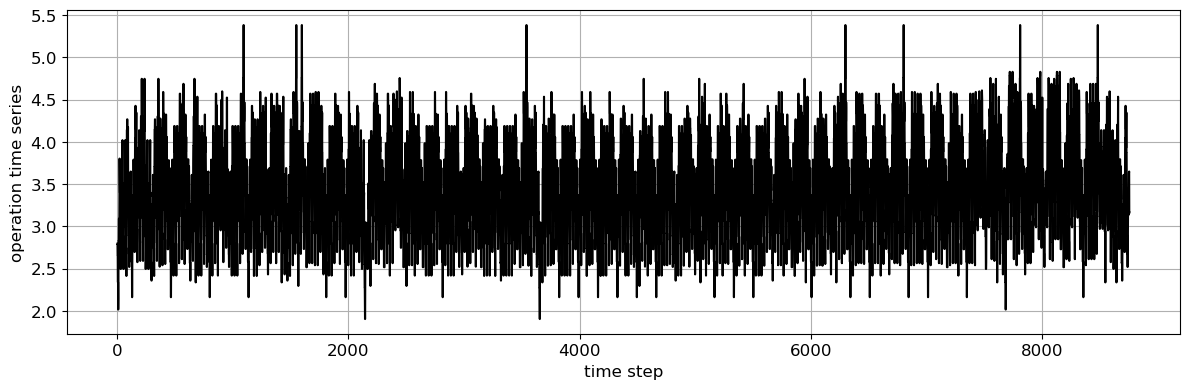

In [ ]:
fig, ax = fn.plotOperation(esM, "Electricity demand", "GermanyRegion")

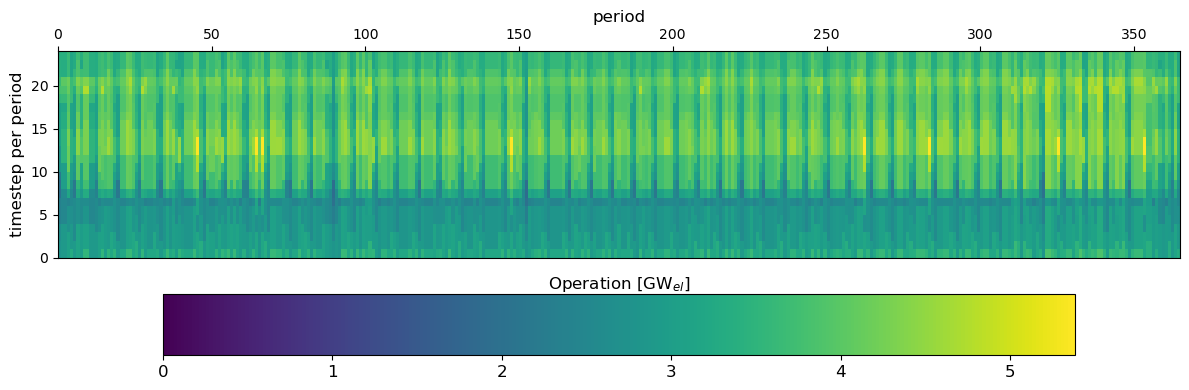

In [ ]:
fig, ax = fn.plotOperationColorMap(esM, "Electricity demand", "GermanyRegion")

### Conversion

Show optimization summary

In [ ]:
esM.getOptimizationSummary("ConversionModel", outputLevel=1)

GermanyRegion
Component                  Property                        Unit                         
Electroylzers              NPVcontribution                 [1e9 Euro]           0.424378
                           TAC                             [1e9 Euro/a]         0.424378
                           capacity                        [GW$_{el}$]          4.877081
                           capexCap                        [1e9 Euro/a]         0.363414
                           commissioning                   [GW$_{el}$]          4.877081
                           decommissioning                 [GW$_{el}$]               0.0
                           invest                          [1e9 Euro]           2.438541
                           investLifetimeExtension         [1e9 Euro]                  0
                           operation                       [GW$_{el}$*h/a]   16832.14911
                                                           [GW$_{el}$*h]     16832.14911
                           opexCap                         [1e9 Euro/a]         0.060964
                           opexOp                          [1e9 Euro/a]              0.0
                           revenueLifetimeShorteningResale [1e9 Euro]                  0
New CCGT plants (hydrogen) NPVcontribution                 [1e9 Euro]           0.124811
                           TAC                             [1e9 Euro/a]         0.124811
                           capacity                        [GW$_{el}$]          1.525874
                           capexCap                        [1e9 Euro/a]         0.092767
                           commissioning                   [GW$_{el}$]          1.525874
                           decommissioning                 [GW$_{el}$]               0.0
                           invest                          [1e9 Euro]           1.068112
                           investLifetimeExtension         [1e9 Euro]                  0
                           operation                       [GW$_{el}$*h/a]     4210.4577
                                                           [GW$_{el}$*h]       4210.4577
                           opexCap                         [1e9 Euro/a]         0.032043
                           opexOp                          [1e9 Euro/a]              0.0
                           revenueLifetimeShorteningResale [1e9 Euro]                  0

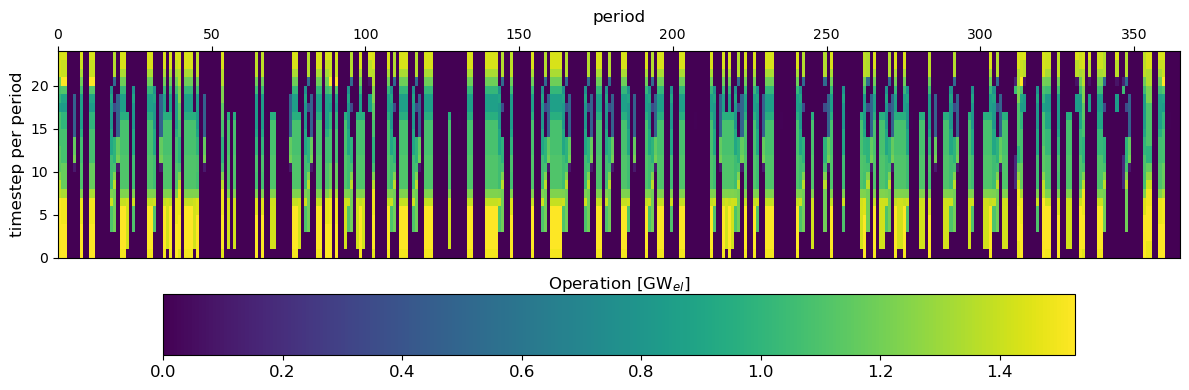

In [ ]:
fig, ax = fn.plotOperationColorMap(esM, "New CCGT plants (hydrogen)", "GermanyRegion")

### Storage

Show optimization summary

In [ ]:
esM.getOptimizationSummary("StorageModel", outputLevel=2)

GermanyRegion
Component               Property           Unit                                
Li-ion batteries        NPVcontribution    [1e9 Euro]                  1.010062
                        TAC                [1e9 Euro/a]                1.010062
                        capacity           [GW$_{el}$*h]              60.112562
                        capexCap           [1e9 Euro/a]                0.889837
                        commissioning      [GW$_{el}$*h]              60.112562
                        invest             [1e9 Euro]                  9.076997
                        operationCharge    [GW$_{el}$*h/a]          6392.688562
                                           [GW$_{el}$*h]            6392.688562
                        operationDischarge [GW$_{el}$*h/a]          5758.987518
                                           [GW$_{el}$*h]            5758.987518
                        opexCap            [1e9 Euro/a]                0.120225
Salt caverns (hydrogen) NPVcontribution    [1e9 Euro]                  0.716143
                        TAC                [1e9 Euro/a]                0.716143
                        capacity           [GW$_{H_{2},LHV}$*h]     1235.216115
                        capexCap           [1e9 Euro/a]                0.012069
                        commissioning      [GW$_{H_{2},LHV}$*h]     1235.216115
                        invest             [1e9 Euro]                  0.135874
                        operationCharge    [GW$_{H_{2},LHV}$*h/a]  10327.298172
                                           [GW$_{H_{2},LHV}$*h]    10327.298172
                        operationDischarge [GW$_{H_{2},LHV}$*h/a]  10327.298172
                                           [GW$_{H_{2},LHV}$*h]    10327.298172
                        opexCap            [1e9 Euro/a]                0.704073

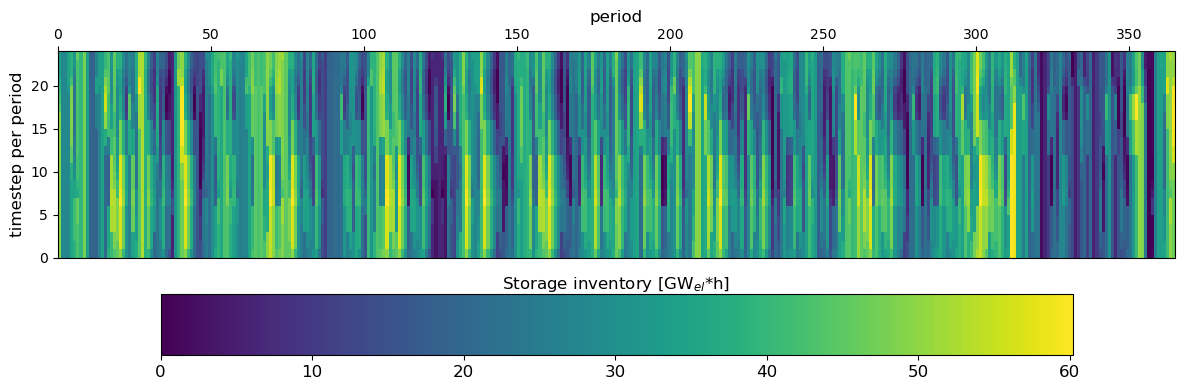

In [ ]:
fig, ax = fn.plotOperationColorMap(
    esM,
    "Li-ion batteries",
    "GermanyRegion",
    variableName="stateOfChargeOperationVariablesOptimum",
)

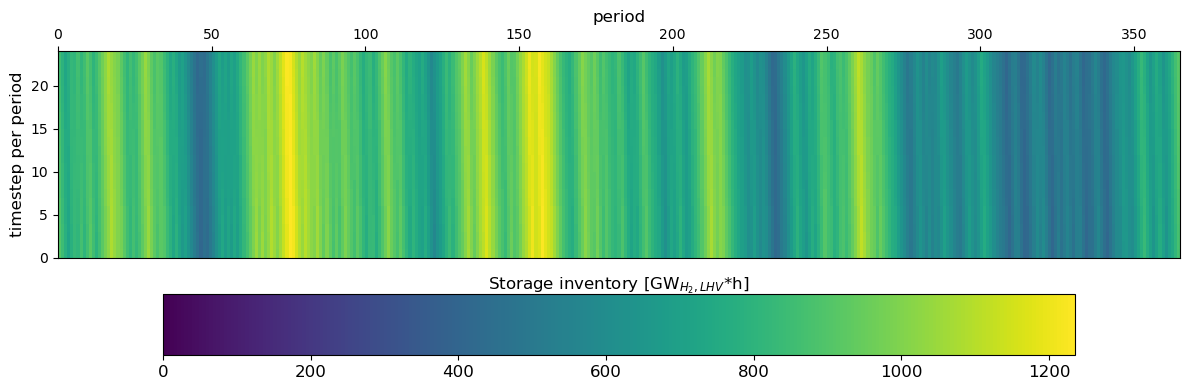

In [ ]:
fig, ax = fn.plotOperationColorMap(
    esM,
    "Salt caverns (hydrogen)",
    "GermanyRegion",
    variableName="stateOfChargeOperationVariablesOptimum",
)